<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/FMNIST_discretize_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [21]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [22]:
# Normalize (important)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)

(60000, 784)


In [23]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [24]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)


model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7804 - loss: 0.6366 - val_accuracy: 0.8485 - val_loss: 0.4230
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8546 - loss: 0.4080 - val_accuracy: 0.8537 - val_loss: 0.4142
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8696 - loss: 0.3649 - val_accuracy: 0.8717 - val_loss: 0.3628
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8785 - loss: 0.3362 - val_accuracy: 0.8700 - val_loss: 0.3572
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8837 - loss: 0.3192 - val_accuracy: 0.8742 - val_loss: 0.3447
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8909 - loss: 0.2992 - val_accuracy: 0.8718 - val_loss: 0.3627
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8949 - loss: 0.2900 - val_accuracy: 0.8783 - val_loss: 0.3425
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8966 - loss: 0.2798 - val_accuracy: 0.

In [26]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8833 - loss: 0.5538
Test accuracy: 0.8833000063896179


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,544 (1.28 MB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 223,030 (871.21 KB)

In [30]:

import matplotlib.pyplot as plt

dense_layers = []

for layer in model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)


w0 = dense_layers[0].get_weights()[0]
w1 = dense_layers[1].get_weights()[0]
w2 = dense_layers[2].get_weights()[0]
w3 = dense_layers[3].get_weights()[0]
w4 = dense_layers[4].get_weights()[0]

b0 = dense_layers[0].get_weights()[1]
b1 = dense_layers[1].get_weights()[1]
b2 = dense_layers[2].get_weights()[1]
b3 = dense_layers[3].get_weights()[1]
b4 = dense_layers[4].get_weights()[1]

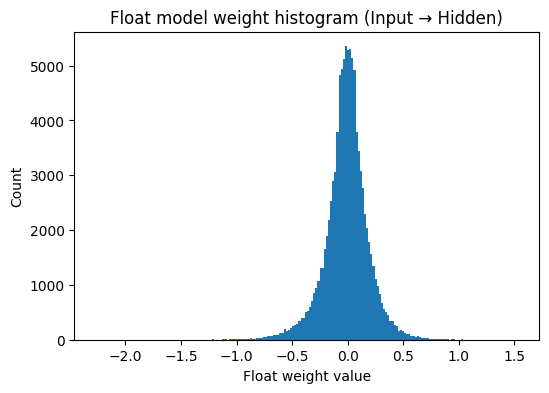

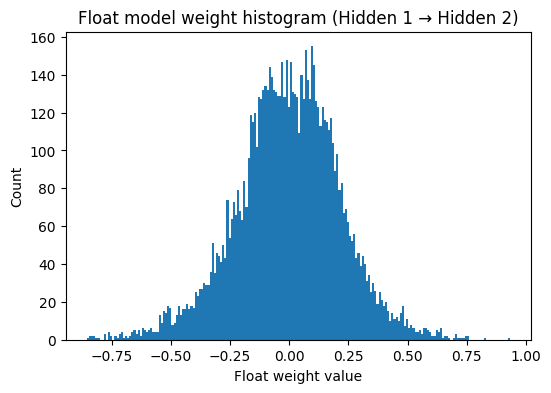

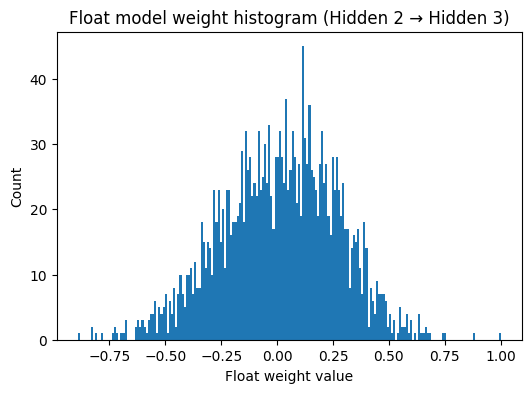

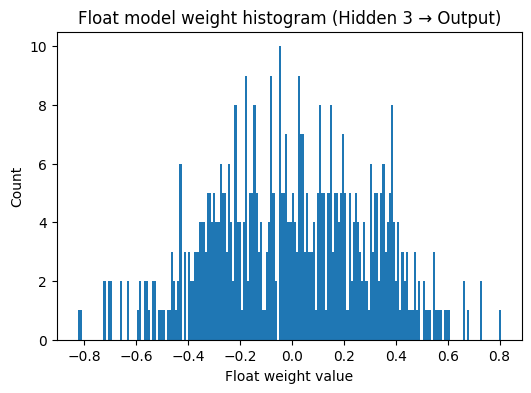

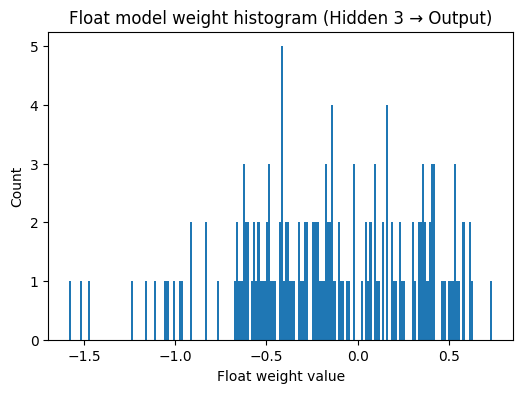

In [31]:
w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w0_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 1 → Hidden 2)")
# plt.xlim([-4, 4])
plt.show()

w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 2 → Hidden 3)")
# plt.xlim([-4, 4])
plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 3 → Hidden 4)")
# plt.xlim([-4, 4])
plt.show()

w4_plot = dense_layers[4].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w4_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 4 → Output)")
# plt.xlim([-4, 4])
plt.show()


In [11]:
# print(f"\n\n{w0}\n\n{w1}\n\n{w2}\n\n{w3}\n\n")

w2.ndim
# w1
# w2
# w3

2

In [12]:

# levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped


In [13]:
snapped_w0 = snap_weights_to_levels(w0, levels)
snapped_w1 = snap_weights_to_levels(w1, levels)
snapped_w2 = snap_weights_to_levels(w2, levels)
snapped_w3 = snap_weights_to_levels(w3, levels)

# snapped_w0 = snap_weights_to_levels(w0, levels).reshape(w0.shape)
# snapped_w1 = snap_weights_to_levels(w1, levels).reshape(w1.shape)
# snapped_w2 = snap_weights_to_levels(w2, levels).reshape(w2.shape)
# snapped_w3 = snap_weights_to_levels(w3, levels).reshape(w3.shape)

snapped_w0
snapped_w1
snapped_w2
snapped_w3



array([[ 0.  , -0.25, -0.25,  0.25, -0.75,  0.25,  0.25,  0.25,  0.  ,
        -0.25,  0.  ,  0.25,  0.25,  0.25, -0.25,  0.25],
       [ 0.25,  0.25,  0.  ,  0.25, -0.25,  0.  , -0.25,  0.25, -0.25,
         0.  , -0.25,  0.  , -0.25, -0.25,  0.  ,  0.  ],
       [ 0.  , -0.25, -0.25, -0.25, -0.25,  0.  ,  0.25,  0.25,  0.  ,
         0.  ,  0.75,  0.  ,  0.25,  0.  , -0.25, -0.25],
       [-0.25,  0.25,  0.25,  0.25,  0.  , -0.25, -0.25,  0.25,  0.75,
         0.25, -0.25, -0.75,  0.25,  0.25,  0.25,  0.25],
       [ 0.  , -0.25,  0.  ,  0.25, -0.25, -0.25, -0.75, -0.75,  0.  ,
         0.25,  0.25,  0.25,  0.  ,  0.25, -0.25, -0.25],
       [ 0.25,  0.  , -0.25,  0.25, -0.25,  0.25, -0.25, -0.25,  0.25,
        -0.25, -0.25,  0.  ,  0.  , -0.25,  0.25,  0.  ],
       [ 0.25,  0.25,  0.25, -0.75,  0.  ,  0.25,  0.25,  0.  ,  0.25,
         0.25,  0.25, -0.25, -0.25,  0.  , -0.25, -0.25],
       [ 0.25,  0.  ,  0.25,  0.25,  0.  ,  0.25, -0.25,  0.25,  0.  ,
         0.25,  0.25,  0.2

In [14]:
# snapped_w0 = snap_weights_to_levels(w0, levels).reshape(w0.shape)
# snapped_w1 = snap_weights_to_levels(w1, levels).reshape(w1.shape)
# snapped_w2 = snap_weights_to_levels(w2, levels).reshape(w2.shape)
# snapped_w3 = snap_weights_to_levels(w3, levels).reshape(w3.shape)

dense_layers[0].set_weights([snapped_w0, b0])
dense_layers[1].set_weights([snapped_w1, b1])
dense_layers[2].set_weights([snapped_w2, b2])
dense_layers[3].set_weights([snapped_w3, b3])



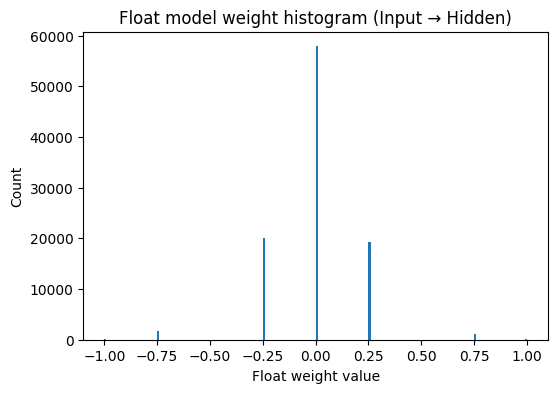

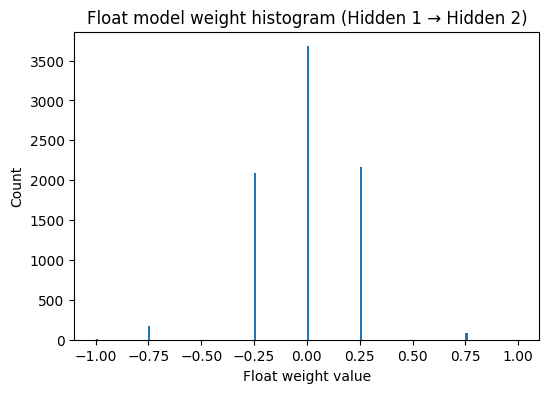

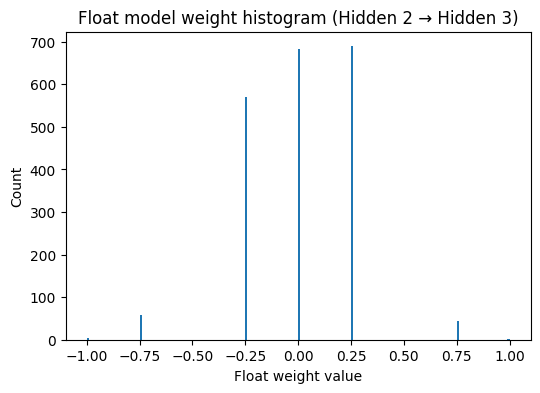

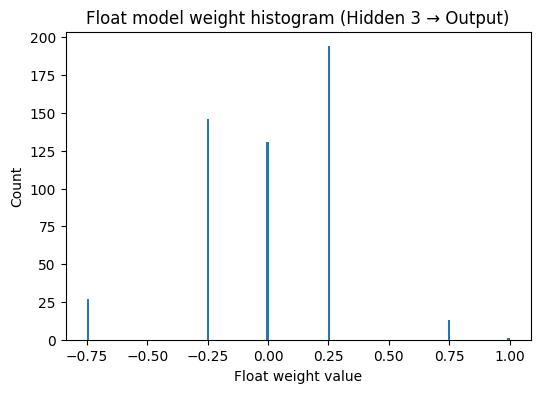

In [15]:
w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w0_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 1 → Hidden 2)")
# plt.xlim([-4, 4])
plt.show()

w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 2 → Hidden 3)")
# plt.xlim([-4, 4])
plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 3 → Output)")
# plt.xlim([-4, 4])
plt.show()


In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7606 - loss: 1.0851
Test accuracy: 0.7605999708175659


In [17]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9354 - loss: 0.1763 - val_accuracy: 0.8867 - val_loss: 0.4239
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9544 - loss: 0.1197 - val_accuracy: 0.8845 - val_loss: 0.4762
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9594 - loss: 0.1072 - val_accuracy: 0.8850 - val_loss: 0.4711
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9619 - loss: 0.1008 - val_accuracy: 0.8863 - val_loss: 0.4897
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9643 - loss: 0.0951 - val_accuracy: 0.8873 - val_loss: 0.5350
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9659 - loss: 0.0909 - val_accuracy: 0.8868 - val_loss: 0.5506
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9656 - loss: 0.0917 - val_accuracy: 0.8855 - val_loss: 0.5407
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9666 - loss: 0.0885 - val_accuracy: 0.

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8872 - loss: 0.8349
Test accuracy: 0.8871999979019165


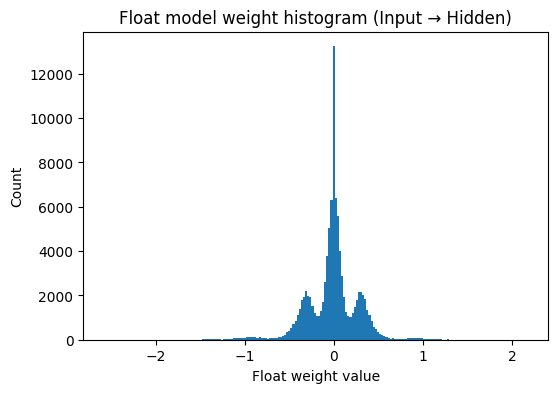

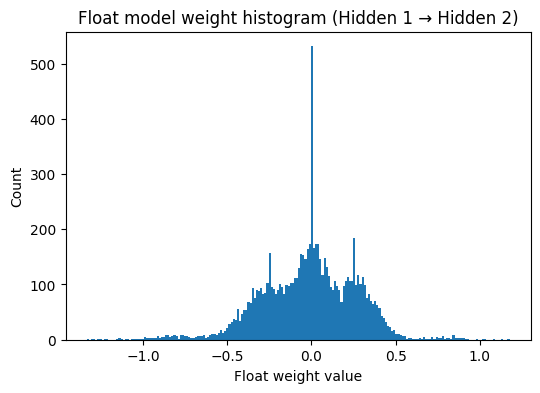

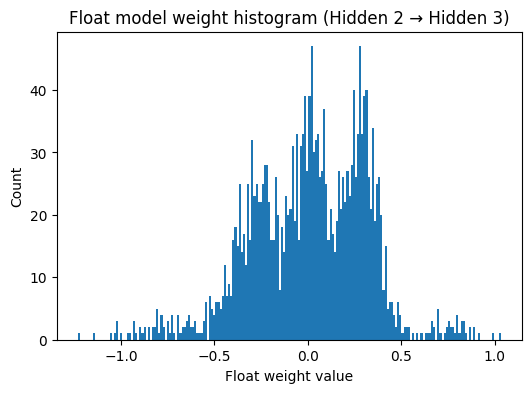

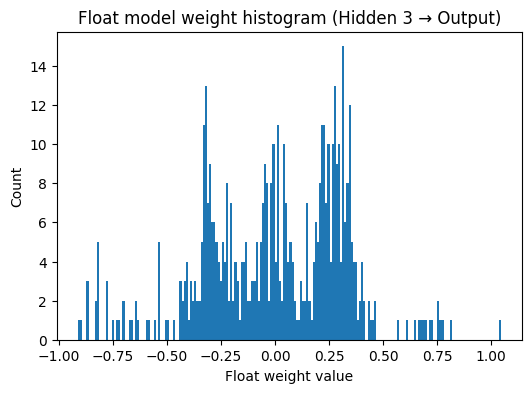

In [19]:
w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w0_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 1 → Hidden 2)")
# plt.xlim([-4, 4])
plt.show()

w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 2 → Hidden 3)")
# plt.xlim([-4, 4])
plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden 3 → Output)")
# plt.xlim([-4, 4])
plt.show()
